# Urban Flood Nowcasting System — Drainage and Rainfall Coupling
### Ministry of Earth Sciences (MoES) Problem Statement — Integrated Prototype

This notebook is the **core scientific processing engine** for a Mumbai urban flood
nowcasting and flood-aware routing system. It integrates two previously separate
notebooks into one coherent pipeline:

1. The **flood-risk engine** (rainfall → DEM/terrain → land cover → Flood Susceptibility
   Index (FSI) → OSM road network → flood-aware routing).
2. The **BMC storm-water drainage network** (manholes as nodes, drainage conduits as
   directed edges, hydraulic geometry) — newly coupled in here as an explicit
   rainfall → runoff → drainage capacity → surcharge → surface-flooding chain.

**Team architecture**

- **A. Flood + drainage scientific engine** — this notebook.
- **B. Live rainfall / radar nowcast API** — built by a teammate; this notebook exposes
  a single `get_rainfall_input(...)` interface so the live feed can be swapped in later
  without touching DEM, land cover, drainage, hydraulics, road-risk or routing code.
- **C. Web dashboard** — built by a teammate; this notebook exports GeoTIFF / GeoPackage /
  GeoJSON / JSON outputs designed to be served through an API.

**Conceptual architecture**

```
                    RAINFALL
                       |
              Rainfall nowcast (get_rainfall_input)
                       |
                Rainfall field (grid, mm)
                       |
              Surface runoff (runoff coefficient x rainfall)
                       |
        +--------------+--------------+
        |                             |
   SURFACE MODEL                 DRAINAGE MODEL
        |                             |
 DEM + slope + flow             BMC drainage graph (G_drain)
 land cover / imperviousness          |
        |                       pipe hydraulic capacity (Manning)
        |                             |
        |                       surcharge / overflow
        |                             |
        +--------------+--------------+
                       |
              SURFACE FLOODING INDICATOR
                       |
             INTEGRATED FLOOD RISK (FSI + drainage coupling)
                       |
              ROAD FLOOD RISK
                       |
          FLOOD-AWARE ROAD GRAPH
                       |
              SHORTEST PATH (normal vs flood-aware)
                       |
                 WEB DASHBOARD / API
```

### Scientific honesty — please read before using these results

This is a **hackathon / prototype** pipeline, not a calibrated, operational hydraulic
model. Throughout the notebook we clearly separate:

- **AVAILABLE DATA** — what actually comes from BMC / OSM / DEM / ESA WorldCover / rainfall
  station records.
- **MODEL ASSUMPTIONS** — parameters we had to introduce ourselves (e.g. Manning's
  roughness `n`, runoff coefficients, a risk-penalty for routing). These are clearly
  labelled `# PROTOTYPE ASSUMPTION` and are configurable in the Configuration section.
  They are **not** official BMC or municipal figures.
- **DERIVED VARIABLES** — quantities we compute from the above (e.g. FSI, hydraulic
  capacity, surcharge, the "surface flood indicator").
- **FUTURE DATA REQUIREMENTS** — see Section 23, "Limitations and Future Deployment".

In particular, this notebook does **not** implement a full 2D shallow-water / hydraulic
model, does **not** use live radar nowcasting (that is a separate workstream), and does
**not** produce physically calibrated flood depths in centimetres. Where a depth cannot
be defensibly computed, we report a **relative flood-severity indicator** instead and say
so explicitly.


## 1. Configuration

All file paths and prototype parameters are centralised here. Anything marked `# PROTOTYPE ASSUMPTION` is a modelling choice we introduced ourselves — not an official BMC/municipal value — and should be replaced with calibrated data before any operational use.

In [21]:

# ============================================================
# CENTRAL CONFIGURATION
# ============================================================
from types import SimpleNamespace

CFG = SimpleNamespace(

    # ---------------- Input files (expected in /content or cwd) ----------------
    RAINFALL_XLSX          = "Cleaned_Combined_Rainfall_2015_23.xlsx",
    STATIONS_XLSX          = "Rainfall_Station_Coordinates.xlsx",
    DEM_TIF                = "P5_PAN_CD_N19_000_E072_000_DEM_30m.tif",
    WORLDCOVER_TIF         = "ESA_WorldCover_10m_2021_v200_N18E072_Map.tif",
    OSM_PBF                = "western-zone-260904.osm.pbf",
    MANHOLES_GEOJSON       = "mumbai_storm_water_manholes.geojson",
    DRAINS_GEOJSON         = "mumbai_storm_water_drains.geojson",

    # ---------------- Study area ----------------
    STUDY_BUFFER_DEG       = 0.05,   # buffer around rainfall-station extent (~5-5.5 km)
    LANDCOVER_BUFFER_DEG   = 0.01,   # small buffer for resampling edge effects
    METRIC_CRS_EPSG        = 32643,  # UTM 43N, used for all length/area calculations

    # ---------------- Rainfall event selection ----------------
    # PROTOTYPE ASSUMPTION: the OLD notebook referenced EVENT_DATE / event_totals /
    # station_map / station_cols without ever defining them in the saved cells we were
    # given (a gap in the source notebook). We restore a sensible, documented definition
    # here: the event is the single calendar day with the highest *city-wide* rainfall
    # total in the historical record, and "event total" per station is that day's summed
    # 15-minute rainfall (mm). Change EVENT_DATE_OVERRIDE to analyse a specific date.
    EVENT_DATE_OVERRIDE    = None,   # e.g. "2021-07-20"; None = auto-pick the wettest day

    # ---------------- FSI weights (unchanged from the original notebook) ----------------
    W_RAINFALL             = 0.45,
    W_BUILTUP              = 0.25,
    W_LOWSLOPE             = 0.20,
    W_WATERBUFFER          = 0.15,

    # ---------------- Runoff model ----------------
    # PROTOTYPE ASSUMPTION: simple imperviousness-based runoff coefficient.
    # C = C_MIN + (C_MAX - C_MIN) * built_up_fraction
    RUNOFF_C_MIN           = 0.15,   # runoff coefficient over fully pervious land
    RUNOFF_C_MAX           = 0.80,   # runoff coefficient over fully built-up/impervious land
    # PROTOTYPE ASSUMPTION: the rainfall "event total" is treated as having fallen over
    # this storm duration, purely to convert a rainfall depth (mm) into an average flow
    # rate (m^3/s) for comparison against pipe capacity. Replace with the actual
    # sub-event hyetograph if/when the live nowcast feed provides one.
    STORM_DURATION_HOURS   = 3.0,

    # ---------------- Hydraulic capacity (Manning's equation) ----------------
    # PROTOTYPE ASSUMPTION: BMC does not supply a Manning roughness coefficient in this
    # dataset. n = 0.013 is a generic value for smooth concrete/RCC storm-water conduits
    # (a commonly cited textbook figure), NOT a calibrated or municipal number.
    MANNING_N              = 0.013,
    MIN_SLOPE              = 1e-4,   # floor applied to non-positive/near-zero conduit slopes

    # ---------------- Surcharge / coupling ----------------
    SURCHARGE_RATIO_THRESHOLD = 1.0,   # Q_in / Q_capacity > this => surcharged
    W_DRAINAGE_IN_RISK        = 0.40,  # weight of drainage-surcharge indicator in integrated risk

    # ---------------- Road flood risk / routing ----------------
    ROAD_BUFFER_M          = 15,       # buffer used for zonal stats on road edges (unchanged)
    RISK_PENALTY           = 15,       # flood-aware routing weight multiplier (unchanged)
    DRAIN_PROXIMITY_M      = 60,       # roads within this distance of a surcharged manhole
                                        # get an added proximity risk term (PROTOTYPE ASSUMPTION)
    W_DRAIN_PROXIMITY       = 0.30,

    # ---------------- Demo origin/destination for routing ----------------
    ORIGIN_LONLAT          = (72.8479, 19.0728),
    DEST_LONLAT            = (72.8311, 18.9750),

    NODATA_VAL             = -9999.0,
)

print("Configuration loaded.")
print("PROTOTYPE ASSUMPTIONS in effect (replace with calibrated/municipal data before "
      "operational use):")
for k in ["RUNOFF_C_MIN", "RUNOFF_C_MAX", "STORM_DURATION_HOURS", "MANNING_N",
          "SURCHARGE_RATIO_THRESHOLD", "W_DRAINAGE_IN_RISK", "DRAIN_PROXIMITY_M",
          "W_DRAIN_PROXIMITY", "RISK_PENALTY"]:
    print(f"  {k} = {getattr(CFG, k)}")


Configuration loaded.
PROTOTYPE ASSUMPTIONS in effect (replace with calibrated/municipal data before operational use):
  RUNOFF_C_MIN = 0.15
  RUNOFF_C_MAX = 0.8
  STORM_DURATION_HOURS = 3.0
  MANNING_N = 0.013
  SURCHARGE_RATIO_THRESHOLD = 1.0
  W_DRAINAGE_IN_RISK = 0.4
  DRAIN_PROXIMITY_M = 60
  W_DRAIN_PROXIMITY = 0.3
  RISK_PENALTY = 15


## 2. Library Installation

In [22]:

!pip install rasterio geopandas pyproj shapely pandas numpy matplotlib openpyxl \
    networkx momepy rasterstats richdem whitebox


  Using cached richdem-0.3.4.tar.gz (329 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of richdem to determine which version is compatible with other requirements. This could take a while.
  Using cached richdem-0.3.3.tar.gz (324 kB)
  Preparing metadata (setup.py) ... done
  Using cached richdem-0.3.2.tar.gz (324 kB)
  Preparing metadata (setup.py) ... done
  Using cached richdem-0.3.1.zip (371 kB)
  Preparing metadata (setup.py) ... done
  Using cached richdem-0.3.0.tar.gz (325 kB)
  Preparing metadata (setup.py) ... done
  Using cached richdem-0.2.0.tar.gz (319 kB)
  Preparing metadata (setup.py) ... done
  Using cached richdem-0.1.0.tar.gz (317 kB)
  Preparing metadata (setup.py) ... done
  Using cached richdem-0.0.11.tar.gz (316 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of richdem to determine which version is compatible with other requirements. This could take a while.
  Using cached richd

## 3. Imports

In [23]:

import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

import networkx as nx
import momepy
from rasterstats import zonal_stats

from shapely.geometry import Point, LineString, mapping

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("All libraries imported successfully.")


All libraries imported successfully.


## 4. Input Data

Verify every required input file is present before doing any processing. Nothing downstream should silently proceed with missing data.

In [24]:

required_files = {
    "Rainfall (15-min station data)": CFG.RAINFALL_XLSX,
    "Rainfall station coordinates":   CFG.STATIONS_XLSX,
    "DEM (30 m)":                     CFG.DEM_TIF,
    "Land cover (ESA WorldCover 10 m)": CFG.WORLDCOVER_TIF,
    "OSM road network (.osm.pbf)":    CFG.OSM_PBF,
    "BMC storm-water manholes":       CFG.MANHOLES_GEOJSON,
    "BMC storm-water drains":         CFG.DRAINS_GEOJSON,
}

print("Input data check:")
missing = []
for label, path in required_files.items():
    ok = os.path.exists(path)
    print(f"  [{'OK' if ok else 'MISSING'}] {label:38s} -> {path}")
    if not ok:
        missing.append(path)

if missing:
    print("\nWARNING: the following files are missing. Upload them to the Colab "
          "runtime (or /content) before running the cells that need them:")
    for m in missing:
        print("   -", m)
else:
    print("\nAll required input files are present.")


Input data check:
  [OK] Rainfall (15-min station data)         -> Cleaned_Combined_Rainfall_2015_23.xlsx
  [OK] Rainfall station coordinates           -> Rainfall_Station_Coordinates.xlsx
  [OK] DEM (30 m)                             -> P5_PAN_CD_N19_000_E072_000_DEM_30m.tif
  [OK] Land cover (ESA WorldCover 10 m)       -> ESA_WorldCover_10m_2021_v200_N18E072_Map.tif
  [OK] OSM road network (.osm.pbf)            -> western-zone-260904.osm.pbf
  [OK] BMC storm-water manholes               -> mumbai_storm_water_manholes.geojson
  [OK] BMC storm-water drains                 -> mumbai_storm_water_drains.geojson

All required input files are present.


## 5. Rainfall Processing

**Available data:** 37 rainfall stations, 15-minute observations, station coordinates.

**Gap being restored here:** the original flood-risk notebook referenced `EVENT_DATE`, `event_totals`, `station_map` and `station_cols` in its FSI/rainfall-gridding cells, but the cells that actually *defined* those variables were not present in the notebook we were given to integrate — they must have existed only in an interactive Colab session. We restore a clearly documented definition below so the pipeline is reproducible top-to-bottom, and keep the exact same variable names so nothing downstream (FSI, routing) needs to change.

In [25]:

# ---------------- 1. Load rainfall + station data ----------------
rainfall = pd.read_excel(CFG.RAINFALL_XLSX)
stations = pd.read_excel(CFG.STATIONS_XLSX)

print("Rainfall shape:", rainfall.shape)
print("Rainfall columns:", rainfall.columns.tolist()[:10], "...")
print("\nStations shape:", stations.shape)
print(stations.head())

# Identify the date/time column and the per-station rainfall columns.
# PROTOTYPE ASSUMPTION: we assume the first datetime-like column is the timestamp and
# every station's column name matches a station name/ID in `stations`. Adjust the
# `date_col` line below if the real column name differs.
date_col_candidates = [c for c in rainfall.columns
                        if "date" in c.lower() or "time" in c.lower()]
date_col = date_col_candidates[0] if date_col_candidates else rainfall.columns[0]
rainfall[date_col] = pd.to_datetime(rainfall[date_col], errors="coerce")

station_name_col = "Station" if "Station" in stations.columns else stations.columns[0]
station_cols = [c for c in rainfall.columns
                if c != date_col and c in stations[station_name_col].astype(str).tolist()]

if not station_cols:
    # Fall back: assume every non-date numeric column in `rainfall` is a station column
    station_cols = [c for c in rainfall.columns
                    if c != date_col and pd.api.types.is_numeric_dtype(rainfall[c])]

print(f"\nDetected {len(station_cols)} station rainfall columns.")

# station_map: NAME/ID -> {"Latitude":..., "Longitude":...}
lat_col = [c for c in stations.columns if "lat" in c.lower()][0]
lon_col = [c for c in stations.columns if "lon" in c.lower()][0]
station_map = {
    str(row[station_name_col]): {"Latitude": row[lat_col], "Longitude": row[lon_col]}
    for _, row in stations.iterrows()
}
# Keep only station_cols that we actually have coordinates for
station_cols = [c for c in station_cols if c in station_map]
print(f"Station columns with matching coordinates: {len(station_cols)}")

# ---------------- 2. Daily totals per station, then pick the event day ----------------
rainfall["_date_only"] = rainfall[date_col].dt.date
daily_totals = rainfall.groupby("_date_only")[station_cols].sum(min_count=1)
daily_city_total = daily_totals.sum(axis=1)

if CFG.EVENT_DATE_OVERRIDE is not None:
    EVENT_DATE = pd.to_datetime(CFG.EVENT_DATE_OVERRIDE)
    event_day = EVENT_DATE.date()
else:
    event_day = daily_city_total.idxmax()
    EVENT_DATE = pd.to_datetime(event_day)

event_totals = daily_totals.loc[[event_day]].reset_index(drop=True)
# event_totals is a 1-row DataFrame indexed [0], columns = station_cols, values = mm for
# the selected event day -- this mirrors how it is consumed downstream:
# event_totals[station_cols].values

print(f"\nSelected rainfall event date: {EVENT_DATE.date()} "
      f"(city-wide total: {daily_city_total.loc[event_day]:.1f} mm)")
print("Per-station totals on event date:")
display(event_totals[station_cols].T.rename(columns={0: "rainfall_mm"}))


Rainfall shape: (93696, 38)
Rainfall columns: ['Index2', 'Andheri', 'B ward', 'Bandra', 'Byculla', 'C ward', 'Chembur', 'Chincholi', 'Colaba', 'D Ward'] ...

Stations shape: (37, 4)
    Column       Matched Station   Latitude  Longitude
0  Andheri  Andheri Fire Station  19.112269  72.840663
1   B ward         B Ward Office  18.961455  72.833321
2   Bandra   Bandra Fire Station  19.050391  72.837477
3  Byculla  Byculla Fire Station  18.972423  72.831959
4   C ward         C Ward Office  18.946123  72.824901

Detected 37 station rainfall columns.
Station columns with matching coordinates: 37

Selected rainfall event date: 2017-08-29 (city-wide total: 9255.7 mm)
Per-station totals on event date:


,rainfall_mm
Andheri,315.720000
B ward,174.480000
Bandra,184.070000
Byculla,249.690000
C ward,154.890000
Chembur,256.600000
Chincholi,199.767500
Colaba,137.590000
D Ward,150.810000
Dahisar,245.100000


## 6. DEM Processing

Clip the 30 m DEM to the Mumbai study area (station extent + buffer). Logic preserved from the original notebook.

Study bounding box (EPSG:4326): left=72.770914, bottom=18.865474, right=73.016364, top=19.297599

--- mumbai_dem_clipped.tif ---
CRS: EPSG:4326 | VALIDATION: CRS is geographic (EPSG:4326)? True
Bounds: BoundingBox(left=72.77069505669999, bottom=19.000004818700003, right=72.99986190669999, top=19.2977828347)
Width x Height: 825 x 1072
Elevation range: -241.69 to 427.74 m | valid pixels: 884400/884400 (100.0%)


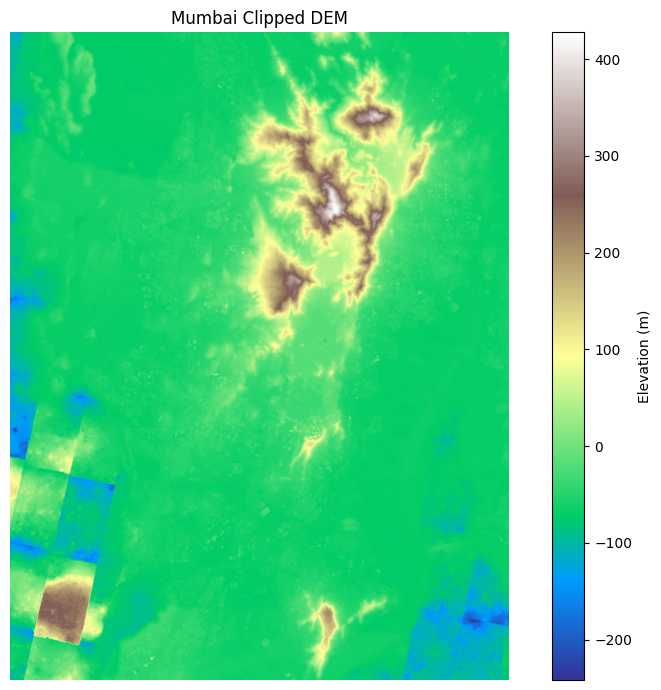

In [26]:

min_lon, max_lon = stations[lon_col].min(), stations[lon_col].max()
min_lat, max_lat = stations[lat_col].min(), stations[lat_col].max()

study_left   = min_lon - CFG.STUDY_BUFFER_DEG
study_right  = max_lon + CFG.STUDY_BUFFER_DEG
study_bottom = min_lat - CFG.STUDY_BUFFER_DEG
study_top    = max_lat + CFG.STUDY_BUFFER_DEG

print(f"Study bounding box (EPSG:4326): left={study_left:.6f}, bottom={study_bottom:.6f}, "
      f"right={study_right:.6f}, top={study_top:.6f}")

with rasterio.open(CFG.DEM_TIF) as src:
    src_crs = src.crs
    src_nodata = src.nodata
    window = from_bounds(study_left, study_bottom, study_right, study_top,
                          transform=src.transform).round_offsets().round_lengths()
    clipped_data = src.read(1, window=window)
    clipped_transform = src.window_transform(window)
    profile = src.profile.copy()
    profile.update({"height": clipped_data.shape[0],
                     "width": clipped_data.shape[1],
                     "transform": clipped_transform})

dem_clipped_path = "mumbai_dem_clipped.tif"
with rasterio.open(dem_clipped_path, "w", **profile) as dst:
    dst.write(clipped_data, 1)

with rasterio.open(dem_clipped_path) as verify:
    print("\n--- mumbai_dem_clipped.tif ---")
    print("CRS:", verify.crs, "| VALIDATION: CRS is geographic (EPSG:4326)?",
          verify.crs.to_epsg() == 4326)
    print("Bounds:", verify.bounds)
    print("Width x Height:", verify.width, "x", verify.height)
    band = verify.read(1)
    valid = band[band != verify.nodata] if verify.nodata is not None else band
    print(f"Elevation range: {valid.min():.2f} to {valid.max():.2f} m | "
          f"valid pixels: {valid.size}/{band.size} ({100*valid.size/band.size:.1f}%)")

plt.figure(figsize=(9, 7))
plt.imshow(np.where(clipped_data == profile.get("nodata"), np.nan, clipped_data), cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Mumbai Clipped DEM")
plt.axis("off")
plt.tight_layout()
plt.savefig("dem_map.png", dpi=150)
plt.show()


## 7. Land Cover Processing

Resample ESA WorldCover (10 m) built-up and water/wetland/mangrove classes onto the 30 m DEM grid as continuous *fractions* (average resampling), preserving the original notebook's approach.

In [27]:

with rasterio.open(dem_clipped_path) as ref:
    ref_transform, ref_crs = ref.transform, ref.crs
    ref_width, ref_height, ref_bounds = ref.width, ref.height, ref.bounds
    dem_valid_mask = ref.read(1) != ref.nodata

with rasterio.open(CFG.WORLDCOVER_TIF) as src:
    src_crs_lc = src.crs
    full_window = rasterio.windows.Window(0, 0, src.width, src.height)
    window = from_bounds(
        ref_bounds.left - CFG.LANDCOVER_BUFFER_DEG, ref_bounds.bottom - CFG.LANDCOVER_BUFFER_DEG,
        ref_bounds.right + CFG.LANDCOVER_BUFFER_DEG, ref_bounds.top + CFG.LANDCOVER_BUFFER_DEG,
        transform=src.transform).round_offsets().round_lengths()
    # Clamp to the dataset's own extent -- a window that pokes even slightly outside
    # the raster (e.g. from the small LANDCOVER_BUFFER_DEG pad) can trigger obscure
    # GDAL tile-read errors on some file/driver combinations.
    window = window.intersection(full_window)

    try:
        lc_array = src.read(1, window=window)
    except rasterio.errors.RasterioIOError as e:
        # Seen in practice: "TIFFReadEncodedTile() failed" / huge row-col numbers on a
        # *windowed* read even though the file opens fine and its full extent/CRS are
        # readable. This points at a corrupted or incompletely-uploaded/synced .tif on
        # this runtime (not a logic bug), most often from an interrupted upload or a
        # Google-Drive-mounted file that hasn't fully synced locally. We retry once,
        # then fall back to a full-band read (slower, but avoids the specific tiled
        # windowed-read code path that is failing) before giving up with a clear message.
        print(f"WARNING: windowed read of {CFG.WORLDCOVER_TIF} failed ({e}). "
              "Retrying once, then falling back to a full-band read...")
        try:
            lc_array = src.read(1, window=window)
        except rasterio.errors.RasterioIOError:
            try:
                full_band = src.read(1)
                lc_array = full_band[window.toslices()]
                print("Fallback full-band read succeeded.")
            except rasterio.errors.RasterioIOError as e2:
                raise RuntimeError(
                    f"Could not read {CFG.WORLDCOVER_TIF} even as a full-band read. "
                    "This strongly indicates the .tif is corrupted or incomplete on "
                    "this runtime (common with an interrupted browser upload or a "
                    "not-fully-synced Drive-mounted file, not a bug in this notebook). "
                    "Re-upload/re-download the ESA WorldCover file and try again, or "
                    "verify its checksum/file size against the source download."
                ) from e2
    lc_window_transform = src.window_transform(window)

print("VALIDATION: land-cover CRS matches DEM CRS?", src_crs_lc == ref_crs)

built_up_mask = (lc_array == 50).astype(np.float32)
water_wetland_mangrove_mask = np.isin(lc_array, [80, 90, 95]).astype(np.float32)

def resample_fraction(mask, src_transform, src_crs, dst_transform, dst_crs, dst_shape):
    dst = np.zeros(dst_shape, dtype=np.float32)
    reproject(source=mask, destination=dst, src_transform=src_transform, src_crs=src_crs,
              dst_transform=dst_transform, dst_crs=dst_crs, resampling=Resampling.average)
    return dst

built_up_fraction = resample_fraction(built_up_mask, lc_window_transform, src_crs_lc,
                                       ref_transform, ref_crs, (ref_height, ref_width))
water_wetland_mangrove_fraction = resample_fraction(water_wetland_mangrove_mask, lc_window_transform,
                                                      src_crs_lc, ref_transform, ref_crs,
                                                      (ref_height, ref_width))

built_up_fraction[~dem_valid_mask] = CFG.NODATA_VAL
water_wetland_mangrove_fraction[~dem_valid_mask] = CFG.NODATA_VAL

landcover_path = "landcover_features.tif"
out_profile = {"driver": "GTiff", "height": ref_height, "width": ref_width, "count": 2,
               "dtype": "float32", "crs": ref_crs, "transform": ref_transform,
               "nodata": CFG.NODATA_VAL}
with rasterio.open(landcover_path, "w", **out_profile) as dst:
    dst.write(built_up_fraction.astype(np.float32), 1)
    dst.write(water_wetland_mangrove_fraction.astype(np.float32), 2)
    dst.set_band_description(1, "built_up_fraction")
    dst.set_band_description(2, "water_wetland_mangrove_fraction")

with rasterio.open(landcover_path) as verify:
    print("VALIDATION: landcover_features.tif grid matches DEM grid exactly?",
          verify.transform == ref_transform and (verify.width, verify.height) == (ref_width, ref_height))
print(f"built_up_fraction   -> mean {built_up_fraction[dem_valid_mask].mean():.3f}")
print(f"water/wetland/mangrove fraction -> mean {water_wetland_mangrove_fraction[dem_valid_mask].mean():.3f}")


VALIDATION: land-cover CRS matches DEM CRS? True
VALIDATION: landcover_features.tif grid matches DEM grid exactly? True
built_up_fraction   -> mean 0.250
water/wetland/mangrove fraction -> mean 0.362


## 8. Terrain Derivatives — Depression Filling, Slope, Flow Accumulation

We keep **both** slope computations from the source notebooks because they are used for different purposes: WhiteboxTools' D8-consistent slope/flow-accumulation (used below for the prototype drainage-catchment allocation), and the original `numpy.gradient`-based `slope_deg` (used, unchanged, inside the FSI formula so FSI results are not altered by this integration).

In [28]:

# Ensure whitebox is installed in *this* runtime (defensive: if the Library
# Installation cell above wasn't run, or Colab reset the runtime since then,
# the import below would otherwise fail with ModuleNotFoundError).
import importlib
import subprocess, sys
if importlib.util.find_spec("whitebox") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "whitebox"], check=True)

from whitebox.whitebox_tools import WhiteboxTools
wbt = WhiteboxTools()
wbt.verbose = False
# WhiteboxTools runs as a separate binary and resolves relative paths against its
# own working directory, NOT the notebook's cwd -- without this it can silently
# "succeed" while writing (or looking for) files in the wrong place, leading to a
# later RasterioIOError: "No such file or directory" when we try to open the output.
wbt.set_working_dir(os.getcwd())

filled_dem_path   = os.path.join(os.getcwd(), "dem_filled.tif")
slope_wbt_path    = os.path.join(os.getcwd(), "dem_slope.tif")
flow_acc_path     = os.path.join(os.getcwd(), "dem_flow_accumulation.tif")
dem_clipped_abspath = os.path.join(os.getcwd(), dem_clipped_path)

print("1. Filling DEM depressions (Wang & Liu)...")
ret = wbt.fill_depressions_wang_and_liu(dem=dem_clipped_abspath, output=filled_dem_path)
if ret != 0 or not os.path.exists(filled_dem_path):
    raise RuntimeError(f"WhiteboxTools fill_depressions_wang_and_liu failed (return code {ret}); "
                        f"expected output at {filled_dem_path}")

print("2. Calculating WhiteboxTools slope...")
ret = wbt.slope(dem=filled_dem_path, output=slope_wbt_path, zfactor=1.0)
if ret != 0 or not os.path.exists(slope_wbt_path):
    raise RuntimeError(f"WhiteboxTools slope failed (return code {ret}); "
                        f"expected output at {slope_wbt_path}")

print("3. Calculating D8 flow accumulation...")
ret = wbt.d8_flow_accumulation(i=filled_dem_path, output=flow_acc_path, out_type="cells")
if ret != 0 or not os.path.exists(flow_acc_path):
    raise RuntimeError(f"WhiteboxTools d8_flow_accumulation failed (return code {ret}); "
                        f"expected output at {flow_acc_path}")

with rasterio.open(flow_acc_path) as fa:
    flow_accumulation = fa.read(1)
    flow_acc_nodata = fa.nodata

print("VALIDATION: flow accumulation grid shape matches DEM grid?",
      flow_accumulation.shape == (ref_height, ref_width))
print(f"Flow accumulation -> min {np.nanmin(flow_accumulation):.1f}, "
      f"max {np.nanmax(flow_accumulation):.1f}")


1. Filling DEM depressions (Wang & Liu)...
2. Calculating WhiteboxTools slope...
3. Calculating D8 flow accumulation...
VALIDATION: flow accumulation grid shape matches DEM grid? True
Flow accumulation -> min 1.0, max 186021.0


In [29]:

# ---------------- Original FSI slope (numpy.gradient), preserved as-is ----------------
with rasterio.open(dem_clipped_path) as src:
    dem = src.read(1).astype(np.float32)
    transform = src.transform
    crs = src.crs
    dem_nodata = src.nodata
    pixel_size_deg = transform.a

valid = (dem != dem_nodata) if dem_nodata is not None else np.ones_like(dem, dtype=bool)
implausible = valid & (dem < -50.0)
print(f"Implausible low-elevation pixels: {int(implausible.sum())}")

NODATA_VAL = CFG.NODATA_VAL
dem_clean = dem.copy()
if dem_nodata is not None:
    dem_clean[dem == dem_nodata] = NODATA_VAL
dem_clean[implausible] = NODATA_VAL
valid_mask = dem_clean != NODATA_VAL

mean_lat = transform.f + (dem.shape[0] / 2) * transform.e
m_per_deg_lat = 111320.0
m_per_deg_lon = 111320.0 * np.cos(np.radians(mean_lat))

dem_for_grad = np.where(valid_mask, dem_clean, np.nan)
dzdy, dzdx = np.gradient(dem_for_grad, pixel_size_deg * m_per_deg_lat, pixel_size_deg * m_per_deg_lon)
slope_rad = np.arctan(np.sqrt(dzdx**2 + dzdy**2))
slope_deg = np.degrees(slope_rad)
slope_deg = np.nan_to_num(slope_deg, nan=0.0)

print("Slope (numpy.gradient, used in FSI) -> min {:.3f}, max {:.3f}, mean {:.3f}".format(
    slope_deg[valid_mask].min(), slope_deg[valid_mask].max(), slope_deg[valid_mask].mean()))

# ---------------- Rasterise the selected rainfall event onto the DEM grid ----------------
rows, cols = np.indices(dem_clean.shape)
grid_lon = transform.c + (cols + 0.5) * transform.a
grid_lat = transform.f + (rows + 0.5) * transform.e
assert grid_lon.shape == dem_clean.shape

points = np.array([[station_map[c]["Longitude"], station_map[c]["Latitude"]] for c in station_cols])
values = event_totals[station_cols].values.astype(float).ravel()

rainfall_grid = griddata(points, values, (grid_lon, grid_lat), method="linear")
nan_mask = np.isnan(rainfall_grid)
if nan_mask.any():
    rainfall_grid[nan_mask] = griddata(points, values, (grid_lon, grid_lat), method="nearest")[nan_mask]
rainfall_grid = np.asarray(rainfall_grid).reshape(dem_clean.shape)

print("VALIDATION: rainfall_grid shape matches DEM grid?", rainfall_grid.shape == dem_clean.shape)
print("Rainfall grid (mm) -> min {:.1f}, max {:.1f}, mean {:.1f}".format(
    rainfall_grid.min(), rainfall_grid.max(), rainfall_grid.mean()))


Implausible low-elevation pixels: 600146
Slope (numpy.gradient, used in FSI) -> min 0.000, max 79.723, mean 9.308
VALIDATION: rainfall_grid shape matches DEM grid? True
Rainfall grid (mm) -> min 150.8, max 391.0, mean 252.0


## 9. Surface Runoff

Convert the rainfall field into a runoff field using an imperviousness-based runoff coefficient. This is the input the drainage model needs — the pipeline explicitly keeps **rainfall**, **runoff**, **drainage flow** and **surface flooding** as distinct quantities, as required.

`runoff_volume = rainfall_depth x runoff_coefficient x contributing_area` (PROTOTYPE ASSUMPTION: a simple linear coefficient; no infiltration/loss dynamics, no time-distributed hyetograph).

In [30]:

with rasterio.open(landcover_path) as lc:
    built_up = lc.read(1)
    water_wetland_mangrove = lc.read(2)
    lc_nodata = lc.nodata

combined_valid = valid_mask & (built_up != lc_nodata)
print(f"Valid cells for FSI/runoff: {int(combined_valid.sum())} / {combined_valid.size}")

def normalize(arr, mask):
    v = arr[mask]
    return np.clip((arr - v.min()) / (v.max() - v.min() + 1e-9), 0, 1)

rainfall_norm = normalize(rainfall_grid, combined_valid)
built_up_norm = normalize(built_up, combined_valid)
slope_norm = normalize(slope_deg, combined_valid)
water_frac = np.clip(water_wetland_mangrove, 0, 1)

# ---- Runoff coefficient + runoff depth/volume (new) ----
built_up_frac_clean = np.clip(np.where(combined_valid, built_up, 0.0), 0, 1)
runoff_coefficient = CFG.RUNOFF_C_MIN + (CFG.RUNOFF_C_MAX - CFG.RUNOFF_C_MIN) * built_up_frac_clean

rainfall_depth_m = np.where(combined_valid, rainfall_grid, 0.0) / 1000.0   # mm -> m
runoff_depth_m = rainfall_depth_m * runoff_coefficient

# cell area in m^2 (approx, using local metre-per-degree conversion computed above)
cell_area_m2 = (pixel_size_deg * m_per_deg_lat) * (pixel_size_deg * m_per_deg_lon)
runoff_volume_m3 = runoff_depth_m * cell_area_m2   # per DEM cell, over the whole event

print(f"Runoff coefficient -> min {runoff_coefficient[combined_valid].min():.3f}, "
      f"max {runoff_coefficient[combined_valid].max():.3f}, "
      f"mean {runoff_coefficient[combined_valid].mean():.3f}")
print(f"Total event runoff volume across study area: "
      f"{runoff_volume_m3[combined_valid].sum():,.0f} m^3 "
      f"(cell size ~{cell_area_m2:.0f} m^2)")


Valid cells for FSI/runoff: 284254 / 884400
Runoff coefficient -> min 0.150, max 0.800, mean 0.299
Total event runoff volume across study area: 20,633,215 m^3 (cell size ~903 m^2)


## 10. BMC Storm-Water Drainage Data

Load the actual BMC manholes (~34,431) and drainage conduits (~34,711). `MANHOLE = drainage graph node`, `DRAIN = directed graph edge (US_NODE_ID -> DS_NODE_ID)`. Logic preserved from the drainage notebook.

In [31]:

manholes = gpd.read_file(CFG.MANHOLES_GEOJSON)
drains = gpd.read_file(CFG.DRAINS_GEOJSON)

print("MANHOLES -> shape:", manholes.shape, "| CRS:", manholes.crs)
print("DRAINS   -> shape:", drains.shape, "| CRS:", drains.crs)
print("\nVALIDATION: manholes/drains CRS matches DEM/road CRS (EPSG:4326)?",
      (manholes.crs is None or manholes.crs.to_epsg() == 4326),
      (drains.crs is None or drains.crs.to_epsg() == 4326))
if manholes.crs is None:
    manholes = manholes.set_crs(4326)
if drains.crs is None:
    drains = drains.set_crs(4326)

drains["length_m"]      = pd.to_numeric(drains["CONDUIT_LE"], errors="coerce")
drains["width_m"]       = pd.to_numeric(drains["CONDUIT_WI"], errors="coerce") / 1000.0
drains["height_m"]      = pd.to_numeric(drains["CONDUIT_HE"], errors="coerce") / 1000.0
drains["us_invert_m"]   = pd.to_numeric(drains["US_INVERT"], errors="coerce")
drains["ds_invert_m"]   = pd.to_numeric(drains["DS_INVERT"], errors="coerce")
drains["shape_clean"]   = drains["SHAPE_1"].astype(str).str.upper()

drains["elevation_drop_m"] = drains["us_invert_m"] - drains["ds_invert_m"]
raw_slope = drains["elevation_drop_m"] / drains["length_m"]

# ---- VALIDATION: negative / zero / missing slopes ----
n_negative_slope = int((raw_slope < 0).sum())
n_zero_slope = int((raw_slope == 0).sum())
n_missing = int(raw_slope.isna().sum())
print(f"\nConduit slope validation: {n_negative_slope} negative-slope conduits "
      f"(possible reversed US/DS or survey noise), {n_zero_slope} zero-slope, "
      f"{n_missing} missing/undefined.")

# Hydraulic slope used downstream is floored at MIN_SLOPE (documented assumption:
# a physically flat/reversed conduit is still assigned a small positive slope so a
# capacity can be estimated at all; it is flagged, not silently "fixed").
drains["slope_raw"] = raw_slope
drains["slope"] = raw_slope.clip(lower=CFG.MIN_SLOPE)
drains["slope_flagged"] = (raw_slope < CFG.MIN_SLOPE)

print("\nDrain length/width/height/slope summary:")
print(drains[["length_m", "width_m", "height_m", "slope"]].describe())
print("\nConduit shapes:", drains["shape_clean"].value_counts().to_dict())

# ---- VALIDATION: node matching between drains and manholes ----
manhole_ids = set(manholes["NODE_ID"].astype(str))
upstream_ids = set(drains["US_NODE_ID"].astype(str))
downstream_ids = set(drains["DS_NODE_ID"].astype(str))
missing_upstream = upstream_ids - manhole_ids
missing_downstream = downstream_ids - manhole_ids

print(f"\nManholes: {len(manhole_ids)} | unique US node IDs: {len(upstream_ids)} "
      f"| unique DS node IDs: {len(downstream_ids)}")
print(f"Upstream IDs NOT found in manholes: {len(missing_upstream)}")
print(f"Downstream IDs NOT found in manholes: {len(missing_downstream)}")
if missing_upstream or missing_downstream:
    print("Examples (upstream):", list(missing_upstream)[:10])
    print("Examples (downstream):", list(missing_downstream)[:10])
else:
    print("All drain endpoints matched to manholes -- no unmatched nodes to investigate.")


MANHOLES -> shape: (34431, 4) | CRS: EPSG:4326
DRAINS   -> shape: (34711, 12) | CRS: EPSG:4326

VALIDATION: manholes/drains CRS matches DEM/road CRS (EPSG:4326)? True True

Conduit slope validation: 26 negative-slope conduits (possible reversed US/DS or survey noise), 119 zero-slope, 0 missing/undefined.

Drain length/width/height/slope summary:
           length_m       width_m      height_m         slope
count  34711.000000  34711.000000  34711.000000  34711.000000
mean      36.019489      4.373725      1.698613      0.006365
std       42.477965      7.837763      1.076986      0.012622
min        1.000000      0.230000      0.230000      0.000100
25%       17.100000      0.800000      0.800000      0.001130
50%       28.300000      1.800000      1.500000      0.002791
75%       36.800000      4.282500      2.338000      0.006679
max     1345.700000    160.000000     12.000000      0.392857

Conduit shapes: {'CIRC': 15558, 'OREC': 10777, 'RECT': 7139, 'ARCH': 1237}

Manholes: 34431 |

## 11. Drainage Graph

Build the directed graph `G_drain`: nodes are manholes (with ground elevation and coordinates), edges are drainage conduits (with geometry, dimensions, inverts and slope).

In [32]:

G_drain = nx.DiGraph()

for _, row in manholes.iterrows():
    node_id = str(row["NODE_ID"])
    G_drain.add_node(
        node_id,
        ground_elev=float(row["GROUND_LEV"]) if pd.notna(row["GROUND_LEV"]) else np.nan,
        x=row.geometry.x,
        y=row.geometry.y,
    )

n_edges_added, n_edges_skipped = 0, 0
for _, row in drains.iterrows():
    us, ds = str(row["US_NODE_ID"]), str(row["DS_NODE_ID"])
    if us not in G_drain or ds not in G_drain:
        n_edges_skipped += 1
        continue
    G_drain.add_edge(
        us, ds,
        length_m=row["length_m"], width_m=row["width_m"], height_m=row["height_m"],
        us_invert_m=row["us_invert_m"], ds_invert_m=row["ds_invert_m"],
        slope=row["slope"], slope_flagged=row["slope_flagged"], shape=row["shape_clean"],
    )
    n_edges_added += 1

print("Drainage graph created.")
print(f"Nodes: {G_drain.number_of_nodes()}, Edges added: {n_edges_added}, "
      f"edges skipped (unmatched node): {n_edges_skipped}")

n_cycles = len(list(nx.simple_cycles(G_drain))) if G_drain.number_of_nodes() < 5000 else None
n_self_loops = nx.number_of_selfloops(G_drain)
print(f"Self-loops: {n_self_loops}")
if n_cycles is not None:
    print(f"Simple cycles detected: {n_cycles} (a strict tree/DAG has 0)")


Drainage graph created.
Nodes: 34431, Edges added: 34711, edges skipped (unmatched node): 0
Self-loops: 0


## 12. Hydraulic Capacity — Manning's Equation

For each conduit we compute a full-flow (pipe-full) hydraulic capacity using Manning's equation `Q = (1/n) * A * R^(2/3) * S^(1/2)`.

- **CIRC** conduits: true circular geometry, `width_m` is the diameter.
- **RECT / OREC / ARCH** conduits: approximated as a rectangular channel `width_m x height_m` (PROTOTYPE ASSUMPTION — OREC "oval-rectangular" and ARCH "arch" sections do not have a simple closed-form area/perimeter from width and height alone; treating them as rectangular slightly overestimates their true cross-sectional area and wetted perimeter).
- Manning's roughness `n` is a single configurable value (see Configuration) — **not** BMC-supplied.

In [33]:

def hydraulic_geometry(row):
    shape = row["shape_clean"]
    w, h = row["width_m"], row["height_m"]
    if pd.isna(w) or pd.isna(h) or w <= 0 or h <= 0:
        return np.nan, np.nan
    if shape == "CIRC":
        d = w  # width_m == height_m == diameter for circular conduits in this dataset
        area = np.pi * (d ** 2) / 4.0
        perimeter = np.pi * d
    else:
        # RECT / OREC / ARCH -> rectangular approximation (documented above)
        area = w * h
        perimeter = 2 * (w + h)
    hydraulic_radius = area / perimeter if perimeter > 0 else np.nan
    return area, hydraulic_radius

geo = drains.apply(hydraulic_geometry, axis=1, result_type="expand")
drains["area_m2"], drains["hydraulic_radius_m"] = geo[0], geo[1]

drains["capacity_m3s"] = (
    (1.0 / CFG.MANNING_N) * drains["area_m2"] *
    (drains["hydraulic_radius_m"] ** (2.0 / 3.0)) *
    (drains["slope"] ** 0.5)
)

print("Hydraulic capacity summary (m^3/s):")
print(drains["capacity_m3s"].describe())
print("\nVALIDATION: any non-finite/negative capacities?",
      int((~np.isfinite(drains["capacity_m3s"])).sum()),
      "non-finite,", int((drains["capacity_m3s"] < 0).sum()), "negative")

# Push capacity + geometry onto the graph edges
cap_lookup = drains.set_index(["US_NODE_ID", "DS_NODE_ID"])["capacity_m3s"].to_dict()
area_lookup = drains.set_index(["US_NODE_ID", "DS_NODE_ID"])["area_m2"].to_dict()
for u, v, d in G_drain.edges(data=True):
    key = (u, v)
    d["capacity_m3s"] = cap_lookup.get(key, np.nan)
    d["area_m2"] = area_lookup.get(key, np.nan)

print("\nCapacity attached to graph edges. Example edge:")
print(list(G_drain.edges(data=True))[0])


Hydraulic capacity summary (m^3/s):
count    34711.000000
mean        52.182574
std        156.966836
min          0.009670
25%          0.759089
50%          5.008409
75%         32.801129
max       4443.561126
Name: capacity_m3s, dtype: float64

VALIDATION: any non-finite/negative capacities? 0 non-finite, 0 negative

Capacity attached to graph edges. Example edge:
('1', '2', {'length_m': 15.8, 'width_m': 2.0, 'height_m': 2.0, 'us_invert_m': 25.245, 'ds_invert_m': 25.225, 'slope': 0.0012658227848100995, 'slope_flagged': False, 'shape': 'RECT', 'capacity_m3s': 6.896304507707477, 'area_m2': 4.0})


## 13. Drainage-Rainfall Coupling — Prototype Catchments and Cumulative Flow

We do not have official BMC drainage-catchment polygons, so **we build a defensible prototype approximation instead of inventing official catchments**: every valid DEM cell's runoff is assigned to its **spatially nearest manhole** (nearest-neighbour proxy catchment). D8 flow accumulation (Section 8) is reported alongside this as supporting terrain context, but the actual node assignment used here is nearest-manhole, which is simple, transparent, and does not pretend to reproduce BMC's real sewer-shed delineation.

Once every node has a local inflow, we propagate flow **downstream through the graph** (local inflow + all upstream edges' outflow) so that `Q_in` on each conduit reflects cumulative catchment contribution, not just its own manhole's local runoff.

In [34]:

# ---------------- 1. Assign each valid DEM cell's runoff to its nearest manhole ----------------
node_ids = list(G_drain.nodes())
node_xy = np.array([[G_drain.nodes[n]["x"], G_drain.nodes[n]["y"]] for n in node_ids])
tree = cKDTree(node_xy)

valid_rows, valid_cols = np.where(combined_valid)
cell_lon = grid_lon[valid_rows, valid_cols]
cell_lat = grid_lat[valid_rows, valid_cols]
cell_runoff = runoff_volume_m3[valid_rows, valid_cols]

_, nearest_idx = tree.query(np.column_stack([cell_lon, cell_lat]))
nearest_node_for_cell = np.array(node_ids)[nearest_idx]

runoff_by_node = pd.Series(cell_runoff).groupby(nearest_node_for_cell).sum()
print(f"Runoff assigned to {len(runoff_by_node)} / {len(node_ids)} manholes "
      f"({100*len(runoff_by_node)/len(node_ids):.1f}% of nodes receive direct catchment runoff).")

# Convert event-total runoff volume (m^3) at each node into an average inflow rate (m^3/s)
storm_seconds = CFG.STORM_DURATION_HOURS * 3600.0
local_inflow_m3s = (runoff_by_node / storm_seconds).to_dict()
nx.set_node_attributes(G_drain, {n: local_inflow_m3s.get(n, 0.0) for n in node_ids}, "local_inflow_m3s")

# ---------------- 2. Propagate flow downstream (topological order if it's a DAG) ----------------
is_dag = nx.is_directed_acyclic_graph(G_drain)
print(f"\nG_drain is a DAG (no cycles): {is_dag}")

cumulative_inflow = {n: G_drain.nodes[n]["local_inflow_m3s"] for n in node_ids}
if is_dag:
    order = list(nx.topological_sort(G_drain))
else:
    # PROTOTYPE FALLBACK: if cycles exist, process nodes in arbitrary order and only
    # accumulate along each edge once, avoiding infinite propagation. This is a
    # documented simplification, not a hydraulically rigorous loop solver.
    order = node_ids
    print("WARNING: cycles detected -- using an approximate single-pass propagation "
          "instead of exact topological accumulation.")

for n in order:
    out_edges = list(G_drain.out_edges(n, data=True))
    for u, v, d in out_edges:
        d["q_in_m3s"] = cumulative_inflow[u]
        cumulative_inflow[v] = cumulative_inflow.get(v, 0.0) + cumulative_inflow[u]

for u, v, d in G_drain.edges(data=True):
    d.setdefault("q_in_m3s", G_drain.nodes[u]["local_inflow_m3s"])

q_in_values = [d["q_in_m3s"] for _, _, d in G_drain.edges(data=True)]
print(f"\nQ_in (cumulative inflow) across all conduits -> "
      f"min {min(q_in_values):.4f}, max {max(q_in_values):.4f}, "
      f"mean {np.mean(q_in_values):.4f} m^3/s")


Runoff assigned to 8248 / 34431 manholes (24.0% of nodes receive direct catchment runoff).

G_drain is a DAG (no cycles): False

Q_in (cumulative inflow) across all conduits -> min 0.0000, max 154.1996, mean 0.1916 m^3/s


## 14. Drainage Overload / Surcharge

`Q_in <= Q_capacity` -> normal drainage. `Q_in > Q_capacity` -> overloaded (surcharged), producing an overflow volume that we route back to the surface model. This is a prototype hydraulic approximation using available public conduit attributes, not a reproduction of BMC's own hydraulic model.

In [35]:

for u, v, d in G_drain.edges(data=True):
    cap = d.get("capacity_m3s", np.nan)
    q_in = d.get("q_in_m3s", 0.0)
    if not np.isfinite(cap) or cap <= 0:
        d["surcharge_ratio"] = np.nan
        d["surcharged"] = False
        d["overflow_m3s"] = 0.0
        continue
    ratio = q_in / cap
    d["surcharge_ratio"] = ratio
    d["surcharged"] = ratio > CFG.SURCHARGE_RATIO_THRESHOLD
    d["overflow_m3s"] = max(0.0, q_in - cap)

surcharged_edges = [(u, v, d) for u, v, d in G_drain.edges(data=True) if d.get("surcharged")]
finite_ratios = [d["surcharge_ratio"] for _, _, d in G_drain.edges(data=True)
                 if np.isfinite(d.get("surcharge_ratio", np.nan))]

print(f"Conduits with a valid capacity/ratio: {len(finite_ratios)} / {G_drain.number_of_edges()}")
print(f"Surcharged conduits (Q_in/Q_capacity > {CFG.SURCHARGE_RATIO_THRESHOLD}): "
      f"{len(surcharged_edges)} ({100*len(surcharged_edges)/max(1,len(finite_ratios)):.1f}% of rated conduits)")

# Downstream (DS) node of every surcharged edge is treated as a surface-surcharge point
surcharged_nodes = set(v for _, v, d in G_drain.edges(data=True) if d.get("surcharged"))
print(f"Distinct manholes downstream of a surcharged conduit: {len(surcharged_nodes)}")


Conduits with a valid capacity/ratio: 34597 / 34597
Surcharged conduits (Q_in/Q_capacity > 1.0): 225 (0.7% of rated conduits)
Distinct manholes downstream of a surcharged conduit: 220


## 15. Surface Flooding — Coupling Surcharge Back to the Surface

We do **not** fabricate a physically calibrated water depth in centimetres. Instead we compute a **relative surface-flood severity indicator** (0-1) per DEM cell, driven by proximity to surcharged manholes and the local overflow volume, and clearly label it as such.

In [36]:

surface_flood_indicator = np.zeros_like(dem_clean, dtype=np.float32)

if surcharged_nodes:
    surcharged_xy = np.array([[G_drain.nodes[n]["x"], G_drain.nodes[n]["y"]] for n in surcharged_nodes])
    surcharged_list = list(surcharged_nodes)
    surcharge_tree = cKDTree(surcharged_xy)

    overflow_by_node = {}
    for u, v, d in G_drain.edges(data=True):
        if d.get("surcharged"):
            overflow_by_node[v] = overflow_by_node.get(v, 0.0) + d.get("overflow_m3s", 0.0)
    max_overflow = max(overflow_by_node.values()) if overflow_by_node else 1.0

    dist_deg, idx = surcharge_tree.query(np.column_stack([grid_lon[combined_valid], grid_lat[combined_valid]]))
    # Convert approximate degree distance to metres for an interpretable falloff radius
    dist_m = dist_deg * m_per_deg_lat
    INFLUENCE_RADIUS_M = 150.0  # PROTOTYPE ASSUMPTION: how far surcharge "spreads" visually
    proximity_score = np.clip(1.0 - dist_m / INFLUENCE_RADIUS_M, 0, 1)

    nearest_node_overflow = np.array([overflow_by_node.get(surcharged_list[i], 0.0) for i in idx])
    severity = proximity_score * (nearest_node_overflow / max_overflow if max_overflow > 0 else 0)

    flat_indicator = np.zeros(combined_valid.sum(), dtype=np.float32)
    flat_indicator[:] = severity
    surface_flood_indicator[combined_valid] = flat_indicator
else:
    print("No surcharged conduits found under current assumptions -- "
          "surface_flood_indicator is all zeros.")

print("Surface flood indicator (relative, 0-1, NOT a calibrated depth) -> "
      f"min {surface_flood_indicator[combined_valid].min():.3f}, "
      f"max {surface_flood_indicator[combined_valid].max():.3f}, "
      f"mean {surface_flood_indicator[combined_valid].mean():.3f}")
print("LIMITATION: this indicator represents relative flood severity/likelihood near "
      "overloaded drainage, not a physically calibrated depth in centimetres.")


Surface flood indicator (relative, 0-1, NOT a calibrated depth) -> min 0.000, max 0.893, mean 0.000
LIMITATION: this indicator represents relative flood severity/likelihood near overloaded drainage, not a physically calibrated depth in centimetres.


## 16. Integrated Flood Risk — FSI + Event-Specific Drainage Coupling

`fsi` (baseline susceptibility, unchanged formula/weights from the original notebook) is combined with the new `surface_flood_indicator` (event-specific, drainage-driven) into a single `integrated_flood_risk`. The two are kept as **separate exported layers** as well, so nobody downstream mistakes FSI for the full hydraulic result.

In [37]:

low_slope_score = 1 - slope_norm
fsi = (CFG.W_RAINFALL * rainfall_norm + CFG.W_BUILTUP * built_up_norm +
       CFG.W_LOWSLOPE * low_slope_score - CFG.W_WATERBUFFER * water_frac)
fsi = np.clip(fsi, 0, 1)
fsi_out = np.where(combined_valid, fsi, CFG.NODATA_VAL)

bins = [0, 0.25, 0.5, 0.75, 1.01]
fsi_cat = np.digitize(fsi, bins) - 1
fsi_cat = np.where(combined_valid, fsi_cat, -1)

print("FSI (baseline susceptibility) -> min {:.3f}, max {:.3f}, mean {:.3f}".format(
    fsi[combined_valid].min(), fsi[combined_valid].max(), fsi[combined_valid].mean()))

with rasterio.open("flood_risk.tif", "w", driver="GTiff", height=dem.shape[0], width=dem.shape[1],
                    count=1, dtype="float32", crs=crs, transform=transform, nodata=CFG.NODATA_VAL) as dst:
    dst.write(fsi_out.astype(np.float32), 1)
    dst.set_band_description(1, "flood_susceptibility_index")
print("Saved flood_risk.tif (baseline FSI only)")

# ---- Integrated risk: FSI (baseline) + drainage-surcharge coupling (event-specific) ----
integrated_flood_risk = np.clip(
    fsi + CFG.W_DRAINAGE_IN_RISK * surface_flood_indicator, 0, 1
)
integrated_out = np.where(combined_valid, integrated_flood_risk, CFG.NODATA_VAL)

with rasterio.open("integrated_flood_risk.tif", "w", driver="GTiff", height=dem.shape[0],
                    width=dem.shape[1], count=1, dtype="float32", crs=crs, transform=transform,
                    nodata=CFG.NODATA_VAL) as dst:
    dst.write(integrated_out.astype(np.float32), 1)
    dst.set_band_description(1, "integrated_flood_risk_fsi_plus_drainage")
print("Saved integrated_flood_risk.tif (FSI + drainage-surcharge coupling)")

print("Integrated flood risk -> min {:.3f}, max {:.3f}, mean {:.3f}".format(
    integrated_flood_risk[combined_valid].min(), integrated_flood_risk[combined_valid].max(),
    integrated_flood_risk[combined_valid].mean()))


FSI (baseline susceptibility) -> min 0.000, max 0.893, mean 0.431
Saved flood_risk.tif (baseline FSI only)
Saved integrated_flood_risk.tif (FSI + drainage-surcharge coupling)
Integrated flood risk -> min 0.000, max 0.981, mean 0.431


## 17. Visualization — Surface, Rainfall, FSI and Drainage Layers

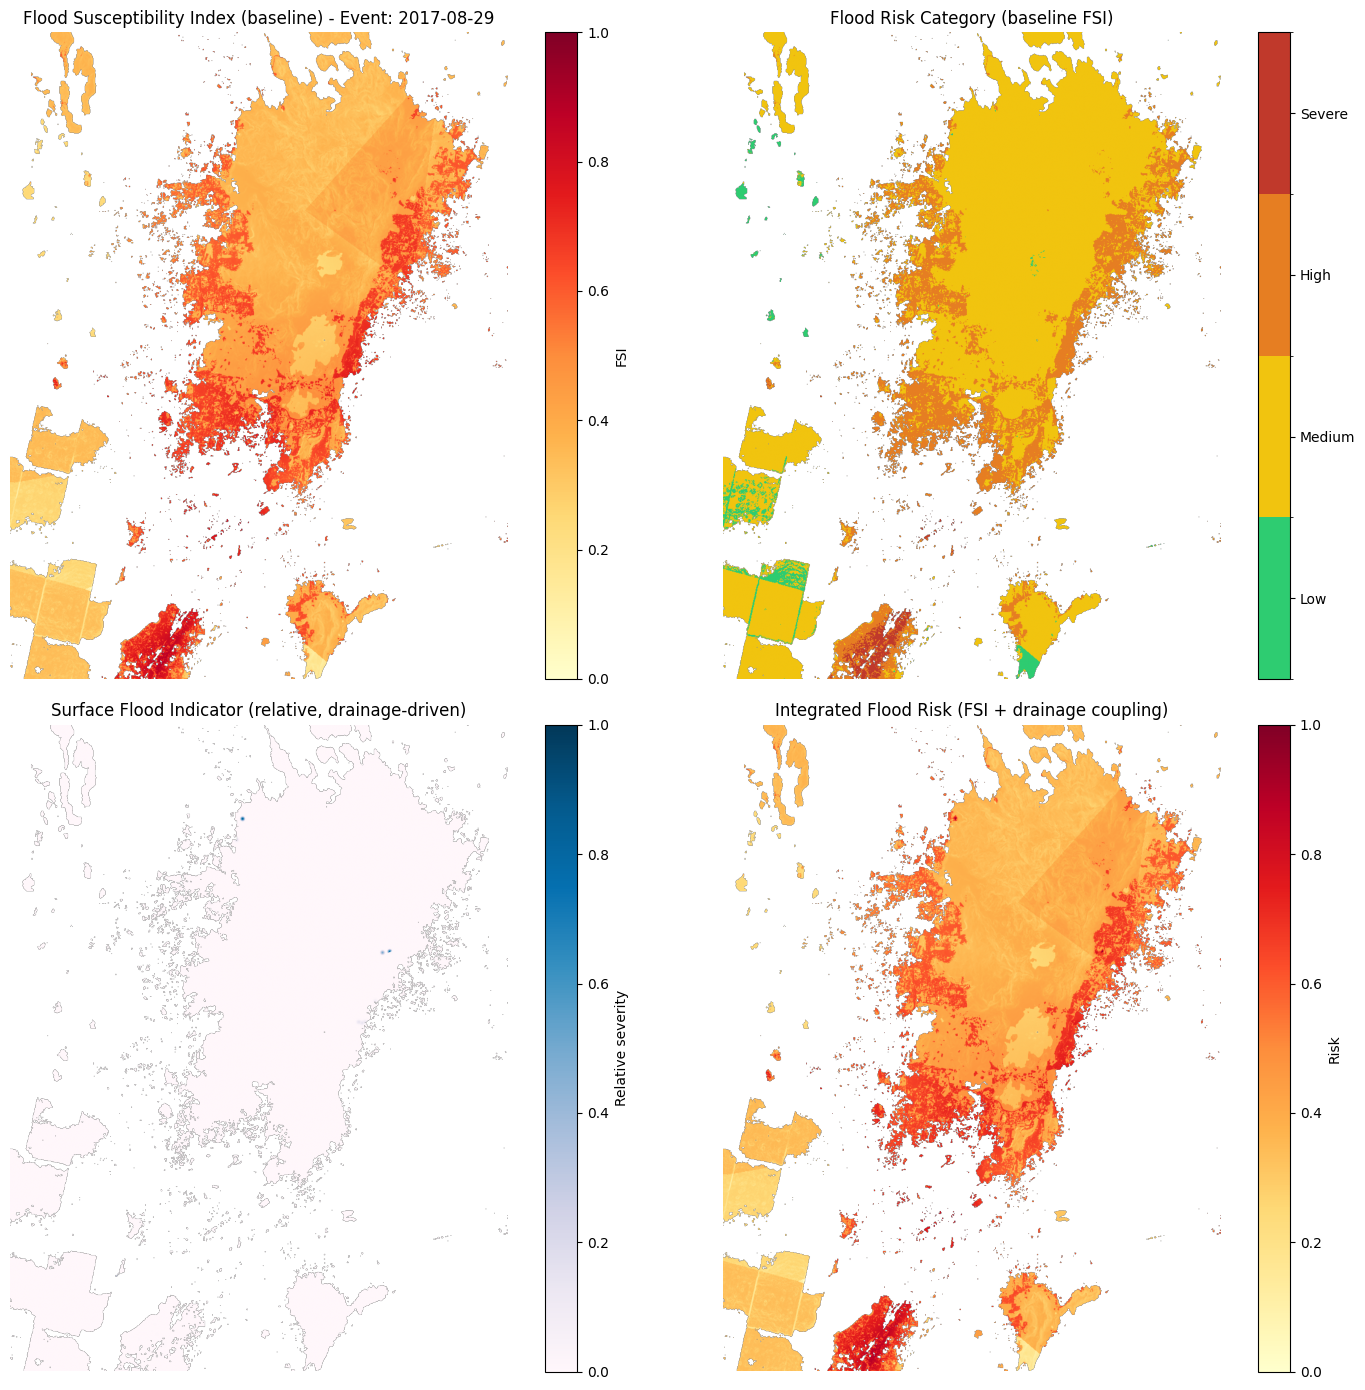

In [38]:

fsi_display = np.where(combined_valid, fsi, np.nan)
cat_display = np.where(combined_valid, fsi_cat, np.nan)
integ_display = np.where(combined_valid, integrated_flood_risk, np.nan)
indicator_display = np.where(combined_valid, surface_flood_indicator, np.nan)

fig, axes = plt.subplots(2, 2, figsize=(15, 14))

im0 = axes[0, 0].imshow(fsi_display, cmap="YlOrRd", vmin=0, vmax=1)
axes[0, 0].set_title(f"Flood Susceptibility Index (baseline) - Event: {EVENT_DATE.date()}")
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], label="FSI")

cmap = mcolors.ListedColormap(["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
im1 = axes[0, 1].imshow(cat_display, cmap=cmap, norm=norm)
axes[0, 1].set_title("Flood Risk Category (baseline FSI)")
axes[0, 1].axis("off")
cbar = plt.colorbar(im1, ax=axes[0, 1], ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["Low", "Medium", "High", "Severe"])

im2 = axes[1, 0].imshow(indicator_display, cmap="PuBu", vmin=0, vmax=1)
axes[1, 0].set_title("Surface Flood Indicator (relative, drainage-driven)")
axes[1, 0].axis("off")
plt.colorbar(im2, ax=axes[1, 0], label="Relative severity")

im3 = axes[1, 1].imshow(integ_display, cmap="YlOrRd", vmin=0, vmax=1)
axes[1, 1].set_title("Integrated Flood Risk (FSI + drainage coupling)")
axes[1, 1].axis("off")
plt.colorbar(im3, ax=axes[1, 1], label="Risk")

plt.tight_layout()
plt.savefig("flood_risk_map.png", dpi=150)
plt.show()


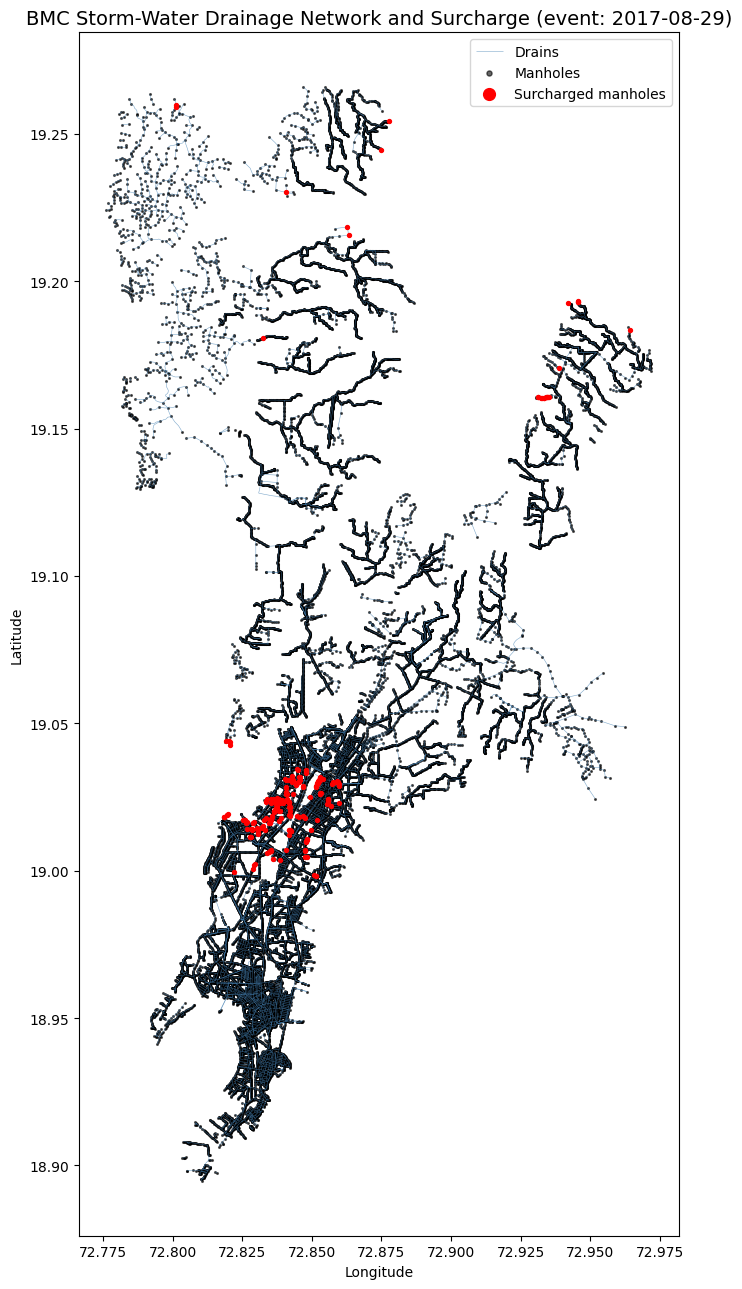

Drainage graph: 34431 nodes, 34597 edges. 220 surcharged manholes highlighted in red.


In [39]:

fig, ax = plt.subplots(figsize=(13, 13))
drains.plot(ax=ax, linewidth=0.4, alpha=0.7, color="steelblue", label="Drains")
manholes.plot(ax=ax, markersize=1.5, alpha=0.6, color="black", label="Manholes")

if surcharged_nodes:
    surch_gdf = manholes[manholes["NODE_ID"].astype(str).isin(surcharged_nodes)]
    surch_gdf.plot(ax=ax, markersize=8, color="red", label="Surcharged manholes", zorder=5)

ax.set_title("BMC Storm-Water Drainage Network and Surcharge (event: "
             f"{EVENT_DATE.date()})", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("drainage_network_map.png", dpi=150)
plt.show()

print(f"Drainage graph: {G_drain.number_of_nodes()} nodes, {G_drain.number_of_edges()} edges. "
      f"{len(surcharged_nodes)} surcharged manholes highlighted in red.")


## 18. OSM Road Network

Preserved from the original notebook: extract Mumbai vehicle roads from the OSM extract, filter by highway class, compute lengths.

In [40]:

pbf_file = CFG.OSM_PBF
layers = gpd.list_layers(pbf_file)
print("OSM layers:", layers)

roads = gpd.read_file(pbf_file, layer="lines")
print("Raw OSM line features:", roads.shape, "| CRS:", roads.crs)

mumbai_roads = roads.cx[study_left:study_right, study_bottom:study_top].copy()
mumbai_roads = mumbai_roads[mumbai_roads["highway"].notna()].copy()
print("Mumbai road features (with a highway tag):", len(mumbai_roads))

vehicle_road_types = [
    "motorway", "motorway_link", "trunk", "trunk_link", "primary", "primary_link",
    "secondary", "secondary_link", "tertiary", "tertiary_link", "unclassified",
    "residential", "living_street", "service", "road", "construction",
]
vehicle_roads = mumbai_roads[mumbai_roads["highway"].isin(vehicle_road_types)].copy()

roads_metric = vehicle_roads.to_crs(epsg=CFG.METRIC_CRS_EPSG)
vehicle_roads["length_m"] = roads_metric.geometry.length.values

road_priority = {"motorway": 5, "motorway_link": 5, "trunk": 5, "trunk_link": 5,
                  "primary": 4, "primary_link": 4, "secondary": 3, "secondary_link": 3,
                  "tertiary": 2, "tertiary_link": 2, "residential": 1, "living_street": 1,
                  "service": 1, "unclassified": 1, "road": 1, "construction": 1}
vehicle_roads["road_priority"] = vehicle_roads["highway"].map(road_priority).fillna(1)
vehicle_roads["has_name"] = vehicle_roads["name"].notna().astype(int)

print(f"Vehicle roads: {len(vehicle_roads)} | total length: "
      f"{vehicle_roads['length_m'].sum()/1000:.1f} km")

vehicle_roads.to_file("mumbai_vehicle_roads.gpkg", layer="roads", driver="GPKG")
print("Saved mumbai_vehicle_roads.gpkg")


OSM layers:                name       geometry_type
0            points               Point
1             lines          LineString
2  multilinestrings     MultiLineString
3     multipolygons        MultiPolygon
4   other_relations  GeometryCollection
Raw OSM line features: (1747422, 11) | CRS: EPSG:4326
Mumbai road features (with a highway tag): 77605
Vehicle roads: 70204 | total length: 9708.1 km
Saved mumbai_vehicle_roads.gpkg


## 19. Road-Level Flood Risk

Each road segment receives an integrated flood-risk attribute from `integrated_flood_risk.tif` (zonal max within the existing 15 m buffer), **plus** an explicit proximity term for roads near a surcharged manhole — capturing localised drainage-driven risk that a coarse 30 m raster may smooth over.

In [41]:

roads_m = gpd.read_file("mumbai_vehicle_roads.gpkg").to_crs(epsg=CFG.METRIC_CRS_EPSG)
roads_m["length_m"] = roads_m.geometry.length

G = momepy.gdf_to_nx(roads_m, approach="primal", multigraph=False)
print(f"Road graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    print(f"Kept largest connected component: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

edges_data = list(G.edges(data=True))
edges_gdf = gpd.GeoDataFrame(
    {"u": [e[0] for e in edges_data], "v": [e[1] for e in edges_data]},
    geometry=[d["geometry"] for _, _, d in edges_data], crs=roads_m.crs)

edges_buffered = edges_gdf.copy()
edges_buffered["geometry"] = edges_gdf.geometry.buffer(CFG.ROAD_BUFFER_M)
edges_buffered_wgs84 = edges_buffered.to_crs(4326)

stats = zonal_stats(edges_buffered_wgs84, "integrated_flood_risk.tif", stats=["max"],
                     nodata=CFG.NODATA_VAL)
edges_gdf["flood_risk_max"] = [s["max"] if s["max"] is not None else 0.0 for s in stats]

# ---- Drainage proximity term ----
surcharged_nodes_xy = np.array([[G_drain.nodes[n]["x"], G_drain.nodes[n]["y"]] for n in surcharged_nodes]) \
    if surcharged_nodes else np.empty((0, 2))
road_centroids_wgs84 = edges_buffered_wgs84.geometry.centroid  # (buffer centroid ~= edge midpoint)

if len(surcharged_nodes_xy) > 0:
    surch_tree = cKDTree(surcharged_nodes_xy)
    cx = road_centroids_wgs84.x.values
    cy = road_centroids_wgs84.y.values
    dist_deg, _ = surch_tree.query(np.column_stack([cx, cy]))
    dist_m = dist_deg * m_per_deg_lat
    proximity_term = np.clip(1.0 - dist_m / CFG.DRAIN_PROXIMITY_M, 0, 1)
else:
    proximity_term = np.zeros(len(edges_gdf))

edges_gdf["drain_proximity"] = proximity_term
edges_gdf["road_flood_risk"] = np.clip(
    edges_gdf["flood_risk_max"] + CFG.W_DRAIN_PROXIMITY * edges_gdf["drain_proximity"], 0, 1)

risk_lookup = {(row.u, row.v): row.road_flood_risk for row in edges_gdf.itertuples()}
for u, v, d in G.edges(data=True):
    r = risk_lookup.get((u, v), 0.0)
    d["flood_risk"] = r
    d["weight_normal"] = d["length_m"]
    d["weight_flood_aware"] = d["length_m"] * (1 + CFG.RISK_PENALTY * r)

print("Road-level flood risk (raster component) -> min {:.3f}, max {:.3f}, mean {:.3f}".format(
    edges_gdf["flood_risk_max"].min(), edges_gdf["flood_risk_max"].max(), edges_gdf["flood_risk_max"].mean()))
print("Road-level flood risk (integrated, with drainage proximity) -> min {:.3f}, max {:.3f}, mean {:.3f}".format(
    edges_gdf["road_flood_risk"].min(), edges_gdf["road_flood_risk"].max(), edges_gdf["road_flood_risk"].mean()))
print("VALIDATION: road-risk coverage -> "
      f"{int((edges_gdf['road_flood_risk'] > 0).sum())}/{len(edges_gdf)} edges have non-zero risk")


Road graph: 105401 nodes, 69861 edges
Kept largest connected component: 13396 nodes, 15582 edges
Road-level flood risk (raster component) -> min 0.000, max 0.961, mean 0.164
Road-level flood risk (integrated, with drainage proximity) -> min 0.000, max 1.000, mean 0.165
VALIDATION: road-risk coverage -> 4007/15582 edges have non-zero risk


## 20. Flood-Aware Routing

Preserved from the original notebook: nearest-node lookup, normal vs. flood-aware shortest path, and route comparison — now driven by the integrated (FSI + drainage) road risk.

In [42]:

def nearest_node(G, lon, lat, crs_graph):
    pt = gpd.GeoSeries([Point(lon, lat)], crs=4326).to_crs(crs_graph).iloc[0]
    nodes = list(G.nodes)
    dists = gpd.GeoSeries([Point(n) for n in nodes], crs=crs_graph).distance(pt)
    return nodes[dists.idxmin()]

origin_node = nearest_node(G, *CFG.ORIGIN_LONLAT, roads_m.crs)
dest_node = nearest_node(G, *CFG.DEST_LONLAT, roads_m.crs)

# VALIDATION: route connectivity
if not nx.has_path(G, origin_node, dest_node):
    raise RuntimeError("No path exists between the chosen origin and destination in "
                        "the (largest-connected-component) road graph.")

normal_route = nx.shortest_path(G, origin_node, dest_node, weight="weight_normal")
flood_aware_route = nx.shortest_path(G, origin_node, dest_node, weight="weight_flood_aware")

def route_stats(route):
    length = sum(G[route[i]][route[i+1]]["length_m"] for i in range(len(route)-1))
    risks = [G[route[i]][route[i+1]]["flood_risk"] for i in range(len(route)-1)]
    return length, max(risks), float(np.mean(risks))

n_len, n_maxrisk, n_avgrisk = route_stats(normal_route)
f_len, f_maxrisk, f_avgrisk = route_stats(flood_aware_route)
affected_segments = sum(1 for i in range(len(flood_aware_route)-1)
                         if G[flood_aware_route[i]][flood_aware_route[i+1]]["flood_risk"] > 0.25)

print(f"Normal route:      length={n_len:.0f} m, max_risk={n_maxrisk:.3f}, avg_risk={n_avgrisk:.3f}")
print(f"Flood-aware route: length={f_len:.0f} m, max_risk={f_maxrisk:.3f}, avg_risk={f_avgrisk:.3f}")
print(f"Extra distance: {f_len - n_len:.0f} m ({100*(f_len - n_len)/n_len:.1f}%)")
print(f"Flood-aware route segments with risk > 0.25: {affected_segments}")


Normal route:      length=15085 m, max_risk=1.000, avg_risk=0.279
Flood-aware route: length=17890 m, max_risk=0.689, avg_risk=0.022
Extra distance: 2805 m (18.6%)
Flood-aware route segments with risk > 0.25: 3


## 21. Route Visualization

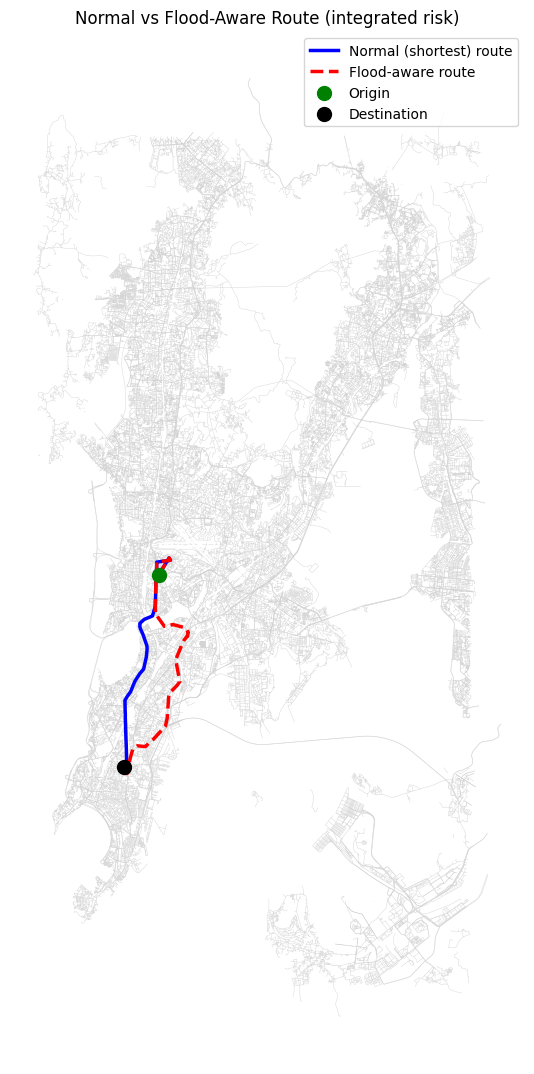

In [43]:

fig, ax = plt.subplots(figsize=(9, 11))
roads_m.plot(ax=ax, color="lightgrey", linewidth=0.3, zorder=1)
ax.plot(*zip(*normal_route), color="blue", linewidth=2.5, label="Normal (shortest) route", zorder=3)
ax.plot(*zip(*flood_aware_route), color="red", linewidth=2.5, linestyle="--",
        label="Flood-aware route", zorder=4)
ax.scatter(*normal_route[0], color="green", s=100, zorder=5, label="Origin")
ax.scatter(*normal_route[-1], color="black", s=100, zorder=5, label="Destination")
ax.set_title("Normal vs Flood-Aware Route (integrated risk)")
ax.legend()
ax.axis("off")
plt.tight_layout()
plt.savefig("route_comparison.png", dpi=150)
plt.show()


## 22. Output Export — Modular Rainfall Interface and Web-Ready Outputs

`get_rainfall_input(...)` is the seam where the live radar/nowcast API can be plugged in later without touching DEM, land cover, drainage, hydraulics, road-risk or routing code — those stages only ever consume `rainfall_grid` (a mm grid on the DEM footprint), whatever produced it.

In [44]:

def get_rainfall_input(time=None, latitude=None, longitude=None, mode="historical"):
    # Modular rainfall input interface.
    #
    # PROTOTYPE: currently returns the historical event grid already computed as
    # `rainfall_grid` in this notebook (mode="historical"). A teammate's live
    # radar/nowcast API is expected to implement mode="live" and return a rainfall
    # grid on the same DEM footprint (same shape, transform and CRS as
    # `mumbai_dem_clipped.tif`) so nothing downstream needs to change.
    if mode == "historical":
        return rainfall_grid
    raise NotImplementedError(
        "Live nowcast/radar rainfall input is being developed separately "
        "(see project architecture, Section 1). Plug the live feed in here."
    )

# ---------------- Machine-readable outputs for the web dashboard ----------------
def route_to_geojson(route, filename, properties):
    line_wgs84 = gpd.GeoSeries([LineString(route)], crs=roads_m.crs).to_crs(4326).iloc[0]
    geojson = {"type": "FeatureCollection",
               "features": [{"type": "Feature", "geometry": mapping(line_wgs84), "properties": properties}]}
    with open(filename, "w") as f:
        json.dump(geojson, f)
    print(f"Saved {filename}")

route_to_geojson(normal_route, "normal_route.geojson",
                  {"length_m": n_len, "max_risk": n_maxrisk, "avg_risk": n_avgrisk})
route_to_geojson(flood_aware_route, "flood_aware_route.geojson",
                  {"length_m": f_len, "max_risk": f_maxrisk, "avg_risk": f_avgrisk,
                   "affected_segments": affected_segments})

edges_gdf.to_crs(4326).to_file("road_risk.gpkg", driver="GPKG")

manholes_out = manholes.copy()
manholes_out["surcharged"] = manholes_out["NODE_ID"].astype(str).isin(surcharged_nodes)
manholes_out.to_file("drainage_manholes_status.gpkg", layer="manholes", driver="GPKG")

drains_export = drains.copy()
edge_status = {(u, v): d for u, v, d in G_drain.edges(data=True)}
drains_export["q_in_m3s"] = [edge_status.get((str(r.US_NODE_ID), str(r.DS_NODE_ID)), {}).get("q_in_m3s")
                              for r in drains_export.itertuples()]
drains_export["capacity_m3s"] = drains_export["capacity_m3s"]
drains_export["surcharged"] = [edge_status.get((str(r.US_NODE_ID), str(r.DS_NODE_ID)), {}).get("surcharged", False)
                                for r in drains_export.itertuples()]
drains_export.to_file("drainage_status.gpkg", layer="drains", driver="GPKG")

with open("mumbai_drainage_graph.pkl", "wb") as f:
    pickle.dump(G_drain, f)

route_summary = {
    "event_date": str(EVENT_DATE.date()),
    "normal_route": {"length_m": n_len, "max_risk": n_maxrisk, "avg_risk": n_avgrisk},
    "flood_aware_route": {"length_m": f_len, "max_risk": f_maxrisk, "avg_risk": f_avgrisk,
                           "affected_segments": affected_segments},
    "extra_distance_m": f_len - n_len,
    "drainage": {
        "n_manholes": G_drain.number_of_nodes(),
        "n_conduits": G_drain.number_of_edges(),
        "n_surcharged_conduits": len(surcharged_edges),
        "n_surcharged_manholes": len(surcharged_nodes),
    },
}
with open("route_summary.json", "w") as f:
    json.dump(route_summary, f, indent=2)

print("\n--- Prototype outputs ready for the web dashboard ---")
for fname in ["flood_risk.tif", "integrated_flood_risk.tif", "flood_risk_map.png",
              "drainage_network_map.png", "road_risk.gpkg", "drainage_manholes_status.gpkg",
              "drainage_status.gpkg", "normal_route.geojson", "flood_aware_route.geojson",
              "route_comparison.png", "route_summary.json", "mumbai_drainage_graph.pkl"]:
    print(" -", fname, "(exists)" if os.path.exists(fname) else "(MISSING)")


Saved normal_route.geojson
Saved flood_aware_route.geojson

--- Prototype outputs ready for the web dashboard ---
 - flood_risk.tif (exists)
 - integrated_flood_risk.tif (exists)
 - flood_risk_map.png (exists)
 - drainage_network_map.png (exists)
 - road_risk.gpkg (exists)
 - drainage_manholes_status.gpkg (exists)
 - drainage_status.gpkg (exists)
 - normal_route.geojson (exists)
 - flood_aware_route.geojson (exists)
 - route_comparison.png (exists)
 - route_summary.json (exists)
 - mumbai_drainage_graph.pkl (exists)


## 23. MoES Problem Statement Coverage

| Requirement | Prototype implementation | Status | Limitation |
|---|---|---|---|
| High-resolution urban flood nowcasting | FSI + drainage-coupled `integrated_flood_risk` raster on a 30 m grid | Partial | Not a calibrated hydraulic depth; "nowcasting" here is historical-event replay, not live forecasting |
| 0-3 hour forecasting | `STORM_DURATION_HOURS` config + `get_rainfall_input()` seam for a live nowcast feed | Interface only | Live 0-3h radar nowcast is a separate workstream (Team B), not implemented here |
| Coupling rainfall with terrain | DEM, slope, D8 flow accumulation, rainfall grid all on one aligned raster grid | Implemented | Terrain-runoff routing is simplified (nearest-manhole catchment, not a full D8-to-node trace) |
| Impervious/urban surfaces | ESA WorldCover built-up fraction drives the runoff coefficient | Implemented | Single linear runoff coefficient; no infiltration, storage or time-distribution |
| Storm-water drainage as a directed graph | `G_drain`: manholes=nodes, conduits=directed edges (US->DS) | Implemented | Graph reflects available BMC attribute data, not verified as-built connectivity |
| Drainage capacity | Manning's equation per conduit, shape-aware area/hydraulic radius | Implemented | `n` and rectangular approximation for OREC/ARCH are prototype assumptions, not calibrated |
| Overcapacity/surcharge detection | `Q_in` (cumulative, topologically propagated) vs `Q_capacity` per conduit | Implemented | Single steady average flow per event, not a transient hydrograph |
| Street-level flooding prediction | `surface_flood_indicator` (relative severity near surcharge) -> road-level risk | Partial | Relative indicator only; no calibrated depth in cm |
| GIS visualization | DEM, rainfall, FSI, drainage network, surcharge, road risk, routes all mapped/exported | Implemented | Static plots + exported layers, not a live map service |
| Flood-safe alternative routes | Flood-aware NetworkX shortest path vs normal route, weighted by integrated risk | Implemented | Demo origin/destination; a real deployment needs a routing API, not a notebook cell |



## 24. Limitations and Future Deployment

**Available data used**
- 37 rainfall stations, 15-minute observations (2015-2023 historical record).
- 30 m DEM; ESA WorldCover 10 m land cover.
- Mumbai OSM road network extract.
- BMC storm-water manholes (~34,431) and drainage conduits (~34,711) with geometry,
  dimensions and invert levels.

**Model assumptions introduced by this prototype (not official BMC/municipal data)**
- Manning's roughness `n = 0.013` for all conduits.
- Runoff coefficient linear in built-up fraction (`RUNOFF_C_MIN`..`RUNOFF_C_MAX`).
- A single event-average storm duration (`STORM_DURATION_HOURS`) used only to convert a
  rainfall depth into an average flow rate.
- Nearest-manhole assignment as a proxy drainage catchment (no official BMC catchment
  polygons were available).
- Rectangular cross-section approximation for OREC/ARCH conduits.
- A distance-based "surcharge spreads to nearby surface cells/roads" falloff
  (`INFLUENCE_RADIUS_M`, `DRAIN_PROXIMITY_M`) with no physical basis beyond proximity.
- `RISK_PENALTY` for flood-aware routing is a tunable weight, not derived from observed
  driver behaviour or safety data.

**What this notebook does NOT claim**
- It is **not** a full 2D shallow-water/hydraulic simulation.
- It does **not** use live radar nowcasting (that is built separately, see
  `get_rainfall_input(mode="live")`).
- Its flood-depth outputs are **not** physically calibrated; only relative
  risk/severity indicators are produced.
- Its hydraulic capacity and surcharge results are **not** validated against BMC's own
  hydraulic model or field observations.

**Future data/deployment requirements**
- Field-validated Manning's roughness per conduit material/condition.
- Official BMC catchment delineation (or a calibrated D8-to-node routing scheme) to
  replace the nearest-manhole proxy.
- A sub-event hyetograph (rainfall intensity over time) rather than a single event
  total, to support genuine 0-3h nowcasting.
- Ground-truthed flood-depth observations for calibrating the surface-flood indicator
  into an actual depth.
- Wrapping this notebook's stages as callable functions/services behind an API for the
  web dashboard (Team C), and swapping `get_rainfall_input()` to the live feed (Team B).
